In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape

(12330, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df.duplicated().sum()

np.int64(125)

In [7]:
df["Revenue"].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


In [8]:
df["Revenue"] = df["Revenue"].astype(bool)
df["Weekend"] = df["Weekend"].astype(bool)

In [9]:
df["VisitorType"].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

In [10]:
df["Month"].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [11]:
df = df.drop_duplicates()
df.shape

(12205, 18)

In [12]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [13]:
conversion_rate = df["Revenue"].mean() * 100
conversion_rate

np.float64(15.632937320770177)

In [14]:
visitor_conversion = df.groupby("VisitorType")["Revenue"].mean() * 100
visitor_conversion

,Revenue
VisitorType,
New_Visitor,24.926167
Other,19.753086
Returning_Visitor,14.092609


In [15]:
pages_by_purchase = df.groupby("Revenue")["ProductRelated"].mean()
pages_by_purchase

,ProductRelated
Revenue,
False,29.050403
True,48.210168


In [16]:
duration_by_purchase = df.groupby("Revenue")["ProductRelated_Duration"].mean()
duration_by_purchase

,ProductRelated_Duration
Revenue,
False,1082.976881
True,1876.209615


In [17]:
bounce_by_purchase = df.groupby("Revenue")["BounceRates"].mean()
bounce_by_purchase

,BounceRates
Revenue,
False,0.023197
True,0.005117


In [18]:
month_conversion = df.groupby("Month")["Revenue"].mean().sort_values(ascending=False) * 100
month_conversion

,Revenue
Month,
Nov,25.486251
Oct,20.947177
Sep,19.196429
Aug,17.551963
Jul,15.277778
Dec,12.661196
May,10.964254
Mar,10.322581
June,10.175439


In [19]:
weekend_conversion = df.groupby("Weekend")["Revenue"].mean() * 100
weekend_conversion

,Revenue
Weekend,
False,15.075968
True,17.453655


In [20]:
traffic_conversion = df.groupby("TrafficType")["Revenue"].mean().sort_values(ascending=False) * 100
traffic_conversion

,Revenue
TrafficType,
16,33.333333
7,30.000000
8,27.696793
20,25.906736
2,21.656865
5,21.538462
10,20.000000
11,19.028340
4,15.478424


In [21]:
exit_by_purchase = df.groupby("Revenue")["ExitRates"].mean()
exit_by_purchase

,ExitRates
Revenue,
False,0.045526
True,0.019555


In [22]:
pagevalue_by_purchase = df.groupby("Revenue")["PageValues"].mean()
pagevalue_by_purchase

,PageValues
Revenue,
False,1.999985
True,27.264518


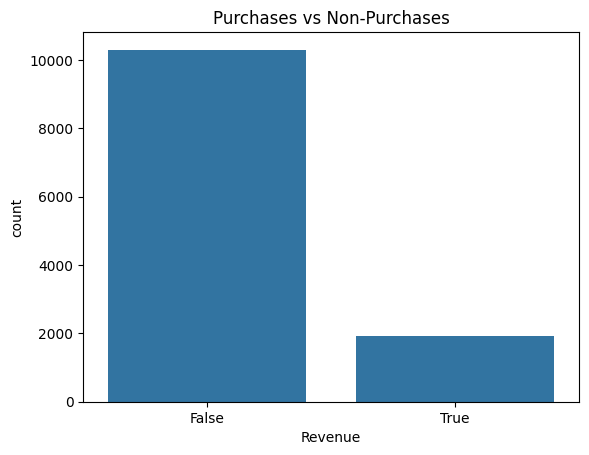

In [23]:
sns.countplot(data=df, x="Revenue")
plt.title("Purchases vs Non-Purchases")
plt.show()

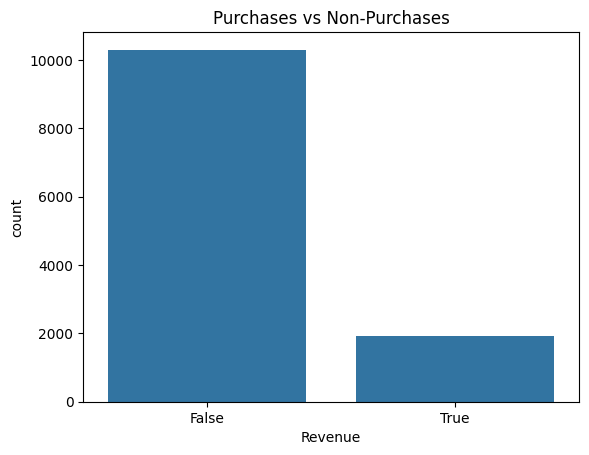

In [24]:
sns.countplot(data=df, x="Revenue")
plt.title("Purchases vs Non-Purchases")
plt.show()

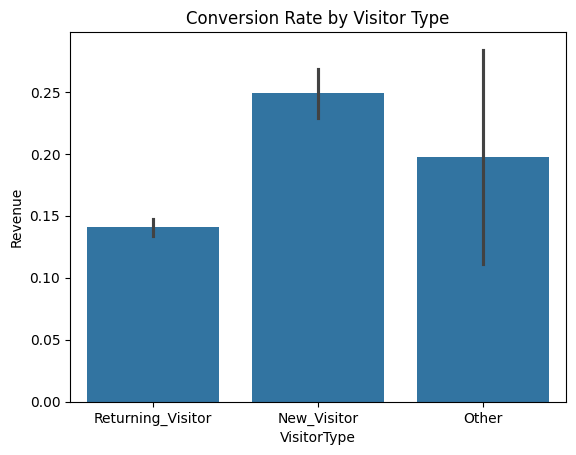

In [25]:
sns.barplot(data=df, x="VisitorType", y="Revenue")
plt.title("Conversion Rate by Visitor Type")
plt.show()

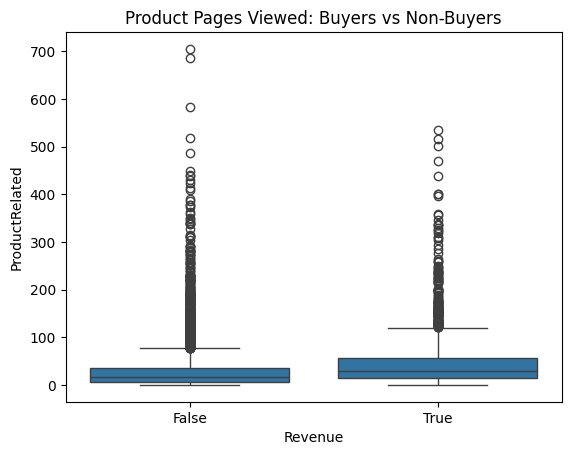

In [26]:
sns.boxplot(data=df, x="Revenue", y="ProductRelated")
plt.title("Product Pages Viewed: Buyers vs Non-Buyers")
plt.show()

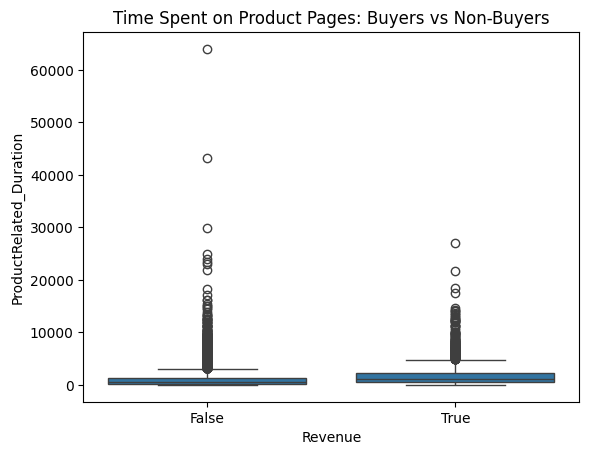

In [27]:
sns.boxplot(data=df, x="Revenue", y="ProductRelated_Duration")
plt.title("Time Spent on Product Pages: Buyers vs Non-Buyers")
plt.show()

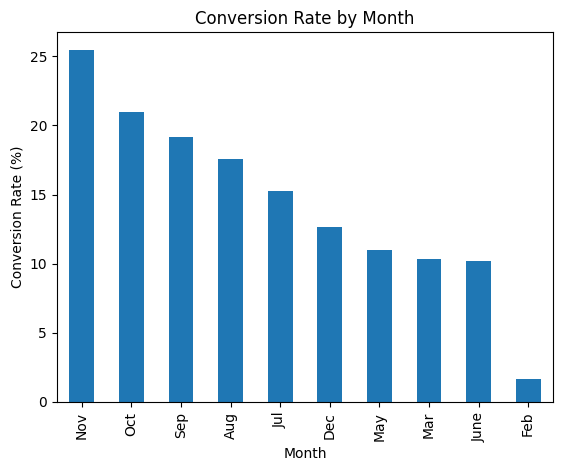

In [28]:
month_conversion.plot(kind="bar")
plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate (%)")
plt.show()

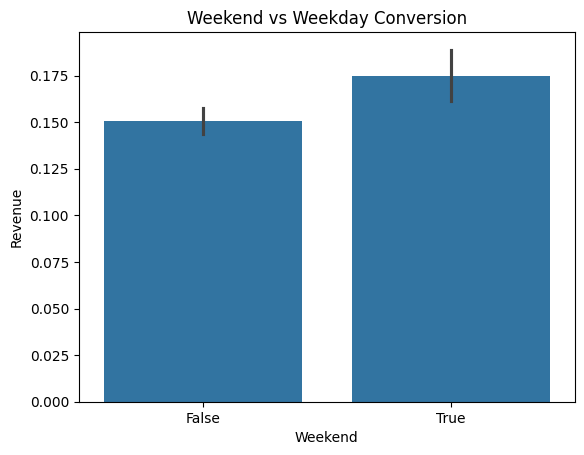

In [29]:
sns.barplot(data=df, x="Weekend", y="Revenue")
plt.title("Weekend vs Weekday Conversion")
plt.show()

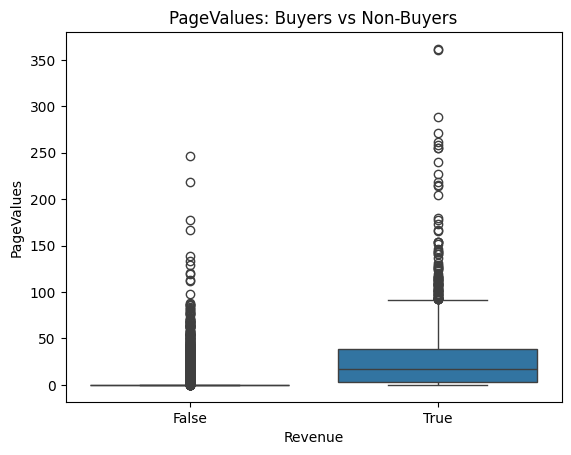

In [31]:
sns.boxplot(data=df, x="Revenue", y="PageValues")
plt.title("PageValues: Buyers vs Non-Buyers")
plt.show()